Model and featured data successfully loaded for comprehensive evaluation.

=== SYSTEM CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      medium       1.00      1.00      1.00       500
      strong       1.00      1.00      1.00       500
        weak       1.00      1.00      1.00       500

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500


Generating confusion matrix plot...


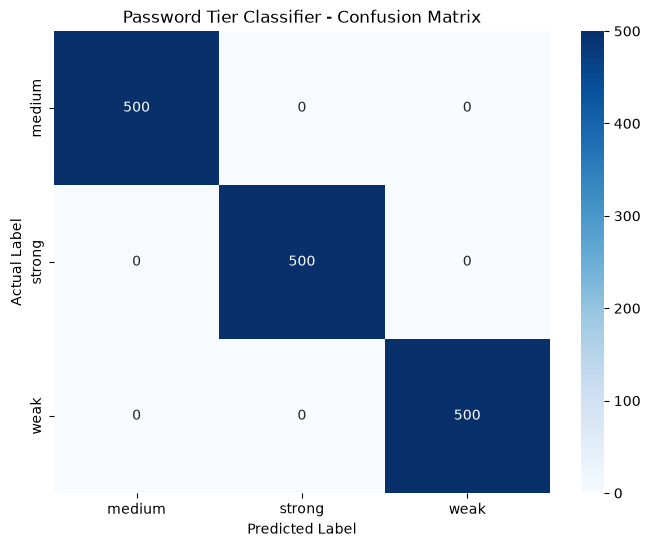

In [1]:
# Cell 1: Load packages and the freshly trained model
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load trained components
model_path = os.path.join("..", "models", "password_model.pkl")
data_path = os.path.join("..", "Data", "passwords_featured.csv")

with open(model_path, "rb") as f:
    model = pickle.load(f)

df = pd.read_csv(data_path)
X = df.drop(columns=["label"])
y = df["label"]

print("Model and featured data successfully loaded for comprehensive evaluation.")

# Cell 2: Classification Report
y_pred = model.predict(X)
print("\n=== SYSTEM CLASSIFICATION REPORT ===")
print(classification_report(y, y_pred))

# Cell 3: Plot and Save Confusion Matrix Dashboard
print("\nGenerating confusion matrix plot...")
cm = confusion_matrix(y, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Password Tier Classifier - Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.savefig("../models/confusion_matrix.png", bbox_inches='tight')
plt.show()